In [25]:
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys 
import os 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works

plt.style.use('../../utils/dune.mplstyle')

In [26]:
#file='/pscratch/sd/l/lmlepin/grid_output/AmBe_top_mod2_test_03-19/FLOW/2x2_QGSP_BERT_HP_AmBe_1773933415_0_TIME_MOD.FLOW.hdf5'
file='/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_Prod_V4/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_AmBe_Prod_V4_0.FLOW.hdf5'
h5_file = h5py.File(file,'r') 
print(f"This file keys: {h5_file.keys()}")

This file keys: <KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']>


In [27]:
trajectories = h5_file['mc_truth/trajectories/data']
segments = h5_file['mc_truth/segments/data']
vertex = h5_file['mc_truth/interactions/data']

print(f"Trajectories keys: {trajectories.dtype.names}")
print(f"Segments keys: {segments.dtype.names}")

Trajectories keys: ('event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel')
Segments keys: ('event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons')


In [28]:
capture_times = []
total_gamma_E = []
gamma_E = []
n_gammas = [] 

In [29]:


for ev in np.unique(trajectories['event_id']):
    my_traj = trajectories[trajectories['event_id']==ev]
    my_vert = vertex[vertex['event_id']==ev]

    ar41_traj = my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131)]
    ar41_traj_id = ar41_traj['parent_id']



    capture_times.extend(my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131) ]['t_start'] - my_vert['t_event'])
    gamma_E.extend(my_traj[(my_traj['pdg_id']==22) & 
                           (my_traj['parent_id']==ar41_traj_id) &
                           (my_traj['start_process']==4) & 
                           (my_traj['start_subprocess']==131)]['E_start'])
    
    n_gammas.append(len(my_traj[(my_traj['pdg_id']==22) & 
                                (my_traj['parent_id']==ar41_traj_id) &
                                (my_traj['start_process']==4) & 
                                (my_traj['start_subprocess']==131)]['E_start']))
    
    total_gamma_E.append(np.sum(my_traj[(my_traj['pdg_id']==22) &
                                        (my_traj['parent_id']==ar41_traj_id) &
                                         (my_traj['start_process']==4) & 
                                         (my_traj['start_subprocess']==131)]['E_start']))

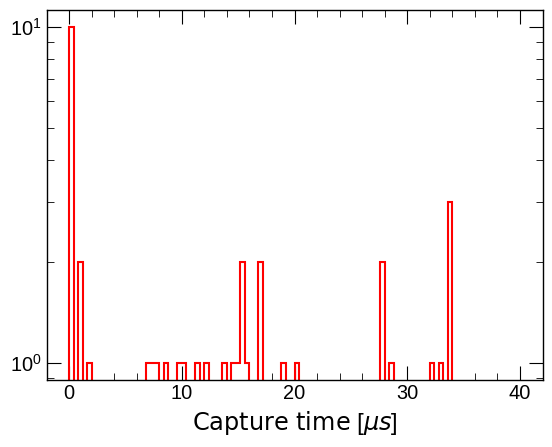

In [30]:
plt.hist(capture_times,bins=100,range=(0.,40),histtype='step',color='red')
plt.xlabel(r'$\text{Capture time}$ [$\mu s$]')
plt.yscale('log')
plt.show()

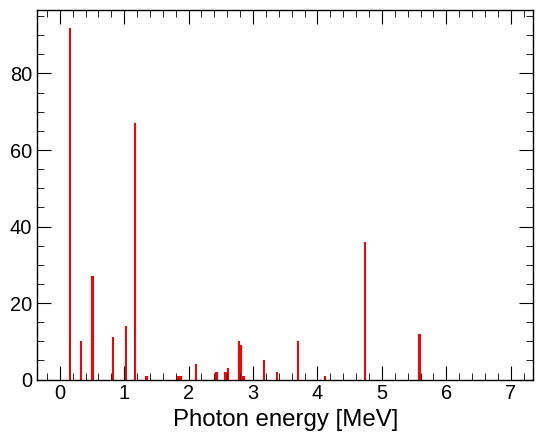

In [31]:
plt.hist(gamma_E,bins=200,range=(0.,7.),color='red')
plt.xlabel('Photon energy [MeV]')
plt.show()

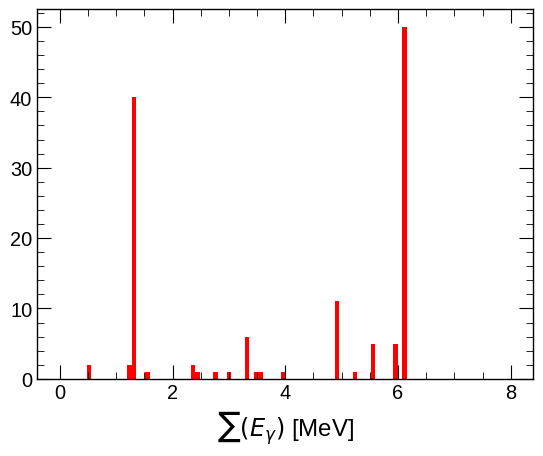

In [32]:
plt.hist(total_gamma_E,bins=100,range=(0.,8.),color='red')
plt.xlabel(r'$\sum(E_{\gamma})$ [MeV]')
plt.show()